In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/data.csv")

In [3]:
df.head()


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


Dataset Overview

In [4]:
df.shape

(95662, 16)

Column Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [6]:
df.columns.tolist()

['TransactionId',
 'BatchId',
 'AccountId',
 'SubscriptionId',
 'CustomerId',
 'CurrencyCode',
 'CountryCode',
 'ProviderId',
 'ProductId',
 'ProductCategory',
 'ChannelId',
 'Amount',
 'Value',
 'TransactionStartTime',
 'PricingStrategy',
 'FraudResult']

Summary Statistics

In [7]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


Check Unique Values

In [8]:
for col in df.columns:
    print(col, df[col].nunique())

TransactionId 95662
BatchId 94809
AccountId 3633
SubscriptionId 3627
CustomerId 3742
CurrencyCode 1
CountryCode 1
ProviderId 6
ProductId 23
ProductCategory 9
ChannelId 4
Amount 1676
Value 1517
TransactionStartTime 94556
PricingStrategy 4
FraudResult 2


Convert Timestamp

In [9]:
df["TransactionStartTime"] = pd.to_datetime(
    df["TransactionStartTime"]
)

In [10]:
df["TransactionStartTime"].head()

0   2018-11-15 02:18:49+00:00
1   2018-11-15 02:19:08+00:00
2   2018-11-15 02:44:21+00:00
3   2018-11-15 03:32:55+00:00
4   2018-11-15 03:34:21+00:00
Name: TransactionStartTime, dtype: datetime64[us, UTC]

Distribution of Numerical Features

In [12]:
num_cols = [
    "Amount",
    "Value",
    "CountryCode",
    "PricingStrategy"
]

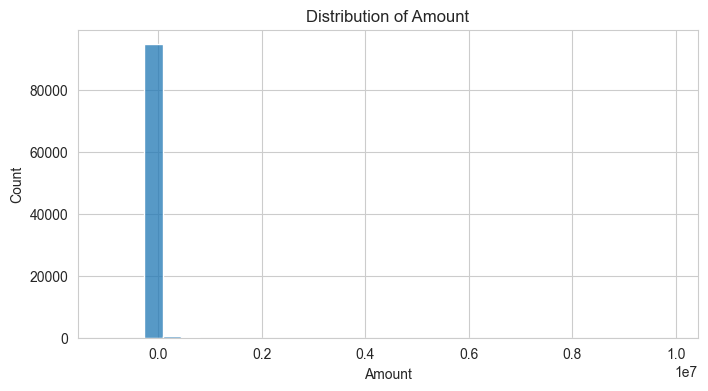

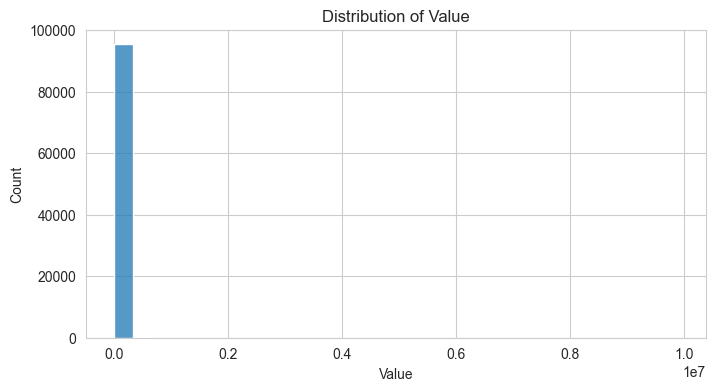

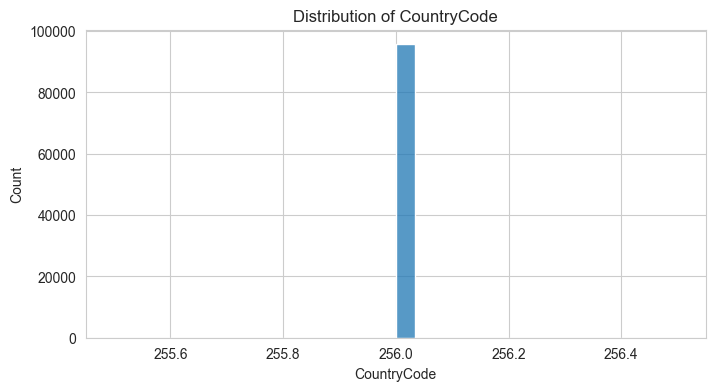

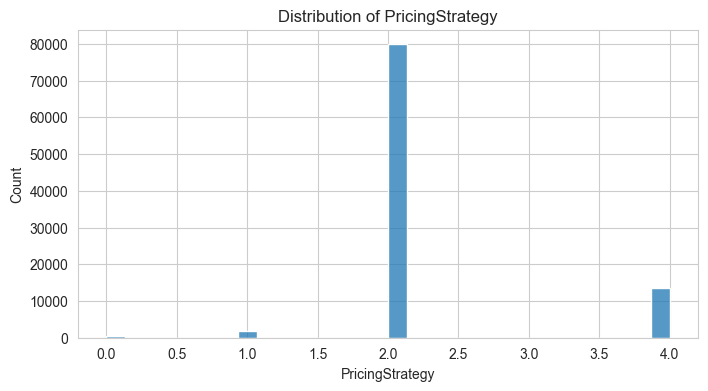

In [13]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30)
    plt.title(f"Distribution of {col}")
    plt.show()

Distribution of Categorical Features

In [14]:
cat_cols = [
    "CurrencyCode",
    "ProviderId",
    "ProductCategory",
    "ChannelId",
    "FraudResult"
]

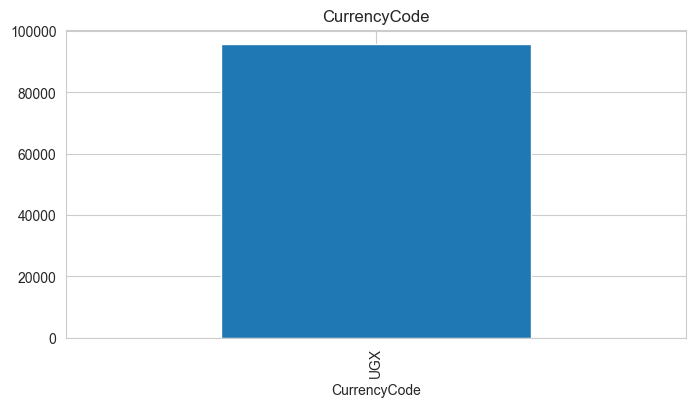

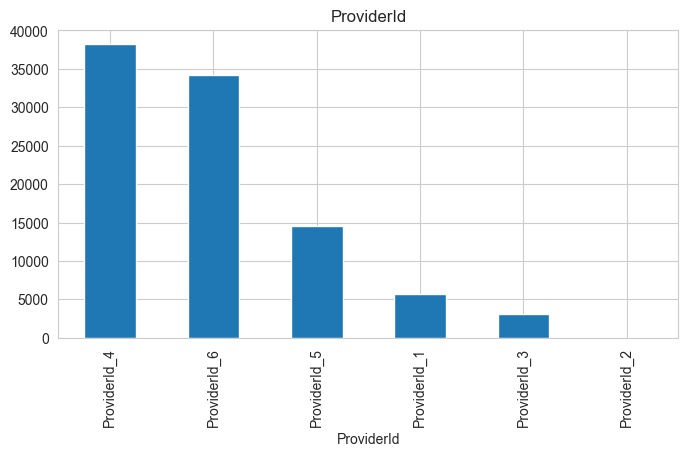

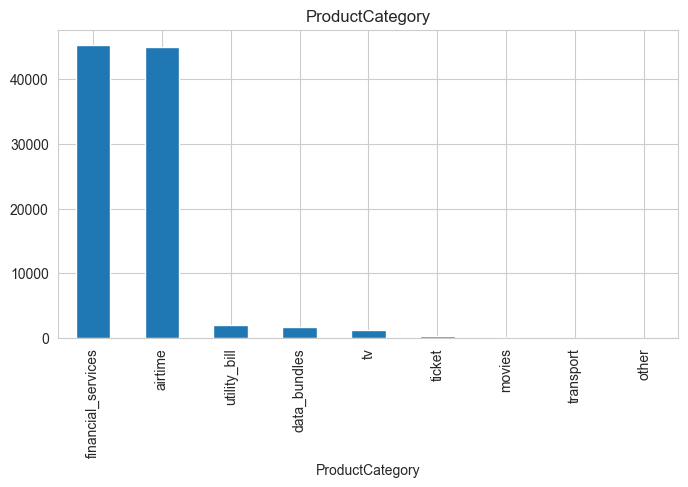

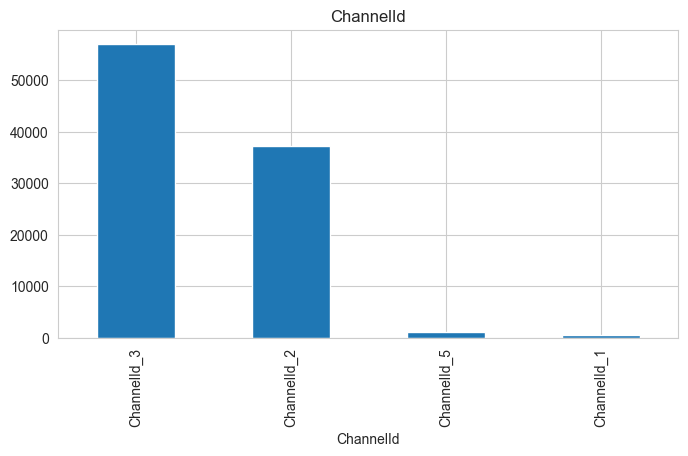

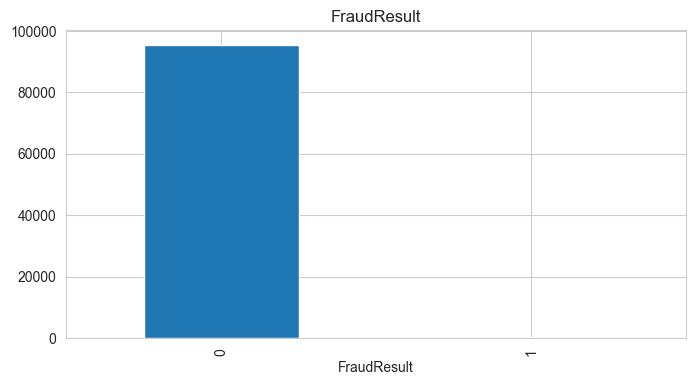

In [15]:
for col in cat_cols:
    
    plt.figure(figsize=(8,4))
    
    df[col].value_counts().plot(
        kind="bar"
    )
    
    plt.title(col)
    plt.show()


Correlation Analysis

In [16]:
corr = df.select_dtypes(
    include=np.number
).corr()

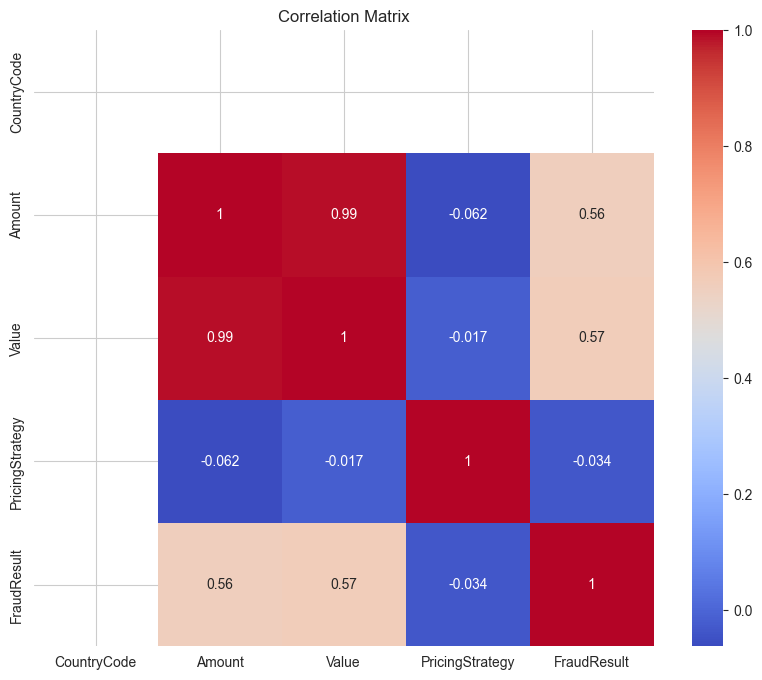

In [17]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

Missing Values

In [ ]:
missing = df.isnull().sum()

missing

missing_pct = (
    df.isnull().mean()*100
)

missing_pct.sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.show()

Outlier Detection

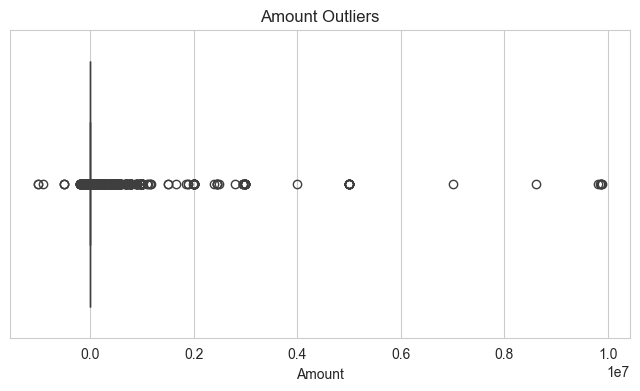

In [21]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Amount"]
)

plt.title("Amount Outliers")
plt.show()

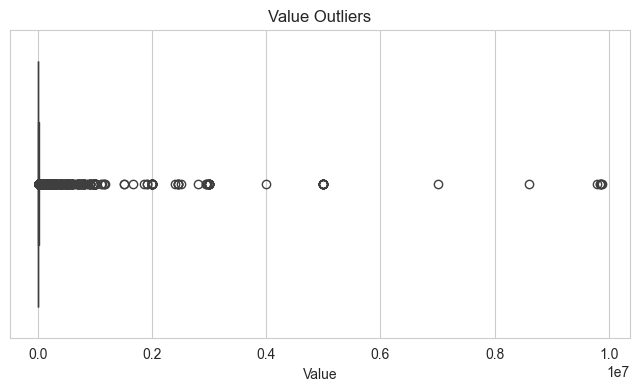

In [22]:
plt.figure(figsize=(8,4))

sns.boxplot(
    x=df["Value"]
)

plt.title("Value Outliers")
plt.show()

Time-Based Exploration

Transactions Per Month

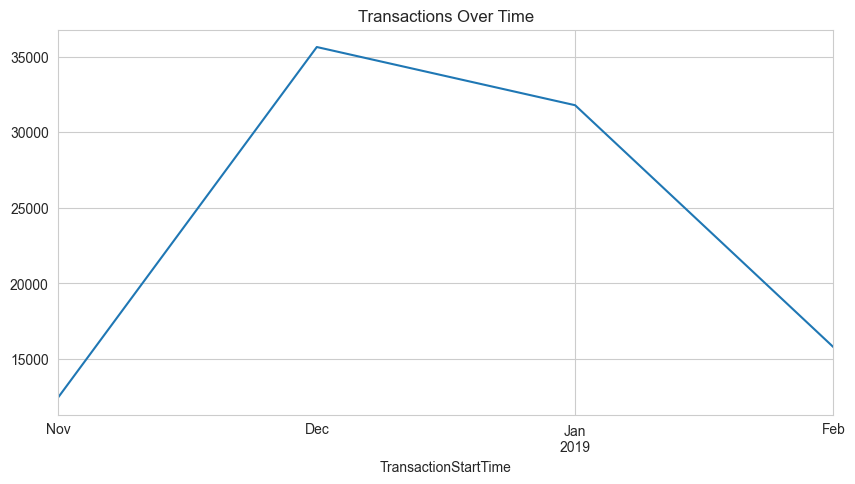

In [24]:
monthly_tx = (
    df
    .set_index("TransactionStartTime")
    .resample("ME")
    .size()
)

monthly_tx.plot(
    figsize=(10,5)
)

plt.title(
    "Transactions Over Time"
)

plt.show()

Customer Activity

Transactions per customer:

In [25]:
customer_tx = (
    df.groupby("CustomerId")
      .size()
)

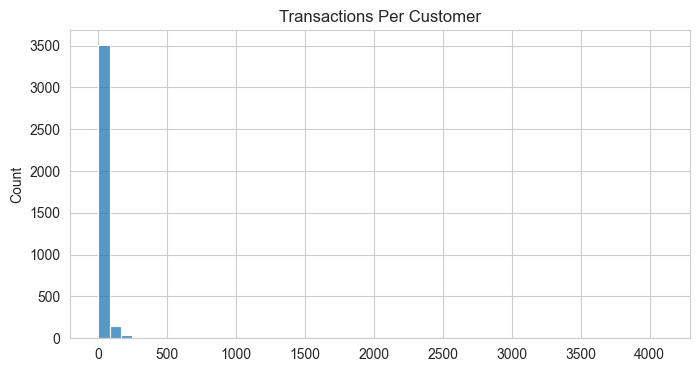

In [26]:
plt.figure(figsize=(8,4))

sns.histplot(
    customer_tx,
    bins=50
)

plt.title(
    "Transactions Per Customer"
)

plt.show()

### Amount Outliers

The Amount feature contains a large number of outliers. Most transactions are concentrated at lower values, while a small number of transactions have extremely high amounts reaching several million units. This suggests a highly right-skewed distribution, which is common in financial transaction data. These outliers may represent legitimate high-value customer activity and should be investigated further before any removal strategy is considered.

### Customer Transaction Frequency

Customer transaction activity is highly uneven. Most customers perform only a small number of transactions, while a small group of customers are extremely active and conduct hundreds or even thousands of transactions. This behavior supports the use of Frequency as an important component of the RFM-based proxy credit risk model.

### Transaction Trends Over Time

Transaction volume increased significantly from November to December, reaching its highest level during December. Activity then declined through January and February. This pattern may reflect seasonal shopping behavior or promotional activity on the platform. However, because the dataset covers a relatively short time period, additional data would be needed to confirm long-term seasonal trends.

# Key Insights from Exploratory Data Analysis

## 1. Transaction Amounts Are Highly Skewed

Most transactions involve relatively small amounts, while a small number of transactions have extremely large values. This indicates a right-skewed distribution and the presence of significant outliers.

## 2. Customer Activity Varies Greatly

Transaction frequency differs substantially across customers. Most customers are relatively inactive, while a small number of customers generate a very large number of transactions. This finding supports the use of Frequency as an important feature in future RFM analysis.

## 3. Transaction Volumes Change Over Time

Transaction activity increased sharply during December before declining in January and February. This suggests potential seasonal effects or changes in customer purchasing behavior.

## 4. Large Transaction Outliers Exist

Several transactions have unusually high monetary values. These observations may represent legitimate customer behavior and should be carefully assessed during feature engineering rather than automatically removed.

## 5. Customer Behavioral Features Are Likely Predictive

The observed variation in transaction frequency, transaction amounts, and activity over time suggests that customer behavioral metrics such as Recency, Frequency, and Monetary value may provide useful signals for constructing a proxy credit risk target.